In [1]:
# Download the sentence transformers package, which we will be using to encode book descriptions/synopses as vectors
# Only need to do once. Uncomment to download yourself 
# %pip install -U sentence_transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

We want to apply some natural language processing techniques to the various string fields that we have. A past project used this thing called SentenceTransformer, which for us will be some blackbox
$$
    \operatorname{SentenceTransformer} : \{ \text{text} \} \to \R^{384} 
$$
which is "continuous" in the sense that sentences that talk about similar things/topics should go to vectors which are close together in some way.

In [3]:
from sentence_transformers import SentenceTransformer

transformer = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [4]:
books = pd.read_csv('../../data/final_book_dataset_cleaned.csv', sep = '\t', 
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
})

In [ ]:
sample = books[(1971 <= books.release_year) & (books.release_year <= 2014)] # our training data spans years 1971 to 2014

In [14]:
sample.book_synopsis = sample.book_synopsis.apply(lambda x : '' if pd.isnull(x) else x)

In [16]:
sample

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,tags,hugo,locus
4548,2009247,The Hawkstone,Jay Williams,1971,1971-10-01,"Henry Z. Walck, Inc.",1914,"Buffalo, New York, USA",0809830965,"""A young New Englander is unaware of the stran...",[],False,False
4549,1336959,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,1971-04-00,Paperback Library,1912,"St. John, New Brunswick, Canada",9781645550112,,NaN,False,False
4550,3092565,Swap Around the Ouija,John Dexter,1971,1971-00-00,Greenleaf Classics,<NA>,NaN,NaN,A swapping group explores the occult; at least...,NaN,False,False
4551,679913,The Sun Grows Cold,Howard Berk,1971,1971-01-00,Dell,1925,"Brookline, Massachusetts, USA",0586039848,,['overpopulation'],False,False
4552,1997735,The Seal-Singing,Rosemary Harris,1971,1971-00-00,Faber and Faber,1923,"London, England, UK",0571096395,"""While spending the summer on a Scottish islan...",['selkies'],False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79651,1772496,Path of the Dead,Timothy Baker,2014,2014-05-00,Ragnarok Publications,<NA>,NaN,9780991360581.0,Nestled on the foot of Tibet's sacred Seche La...,"['Buddhism', 'Fantasy', 'Thriller']",False,False
79652,2621242,Ure Infectus,Caleb Wachter,2014,2014-09-01,Caleb Wachter,<NA>,NaN,9781632010148.0,,[],False,False
79653,3212540,Exile,Chris Ward,2014,2014-01-14,AMMFA Publishing,<NA>,NaN,9781973266136.0,,NaN,False,False
79654,1786194,Superheroes Anonymous,Lexie Dunne,2014,2014-11-18,Harper Voyager Impulse,<NA>,NaN,9780062369116.0,,['superhero'],False,False


Let's see if the book synopses tell us anything distinguishing between winners and everything else.

We start off with the Locus winners vs nonwinners...

In [17]:
locus = sample[sample.locus]
locus_embed = transformer.encode(np.array(locus.book_synopsis))

In [18]:
nonlocus = sample[~(sample.locus)]
nonlocus_embed  = transformer.encode(np.array(nonlocus.book_synopsis)) # could take a bit

In [20]:
sample_embed = transformer.encode(np.array(sample.book_synopsis)) # we need this to fit PCA

To do some plotting, we'll use PCA to get a 3-dimensional slice of the data.

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

pca.fit(sample_embed)

locus_embed3d = pca.transform(locus_embed)

nonlocus_embed3d = pca.transform(nonlocus_embed)

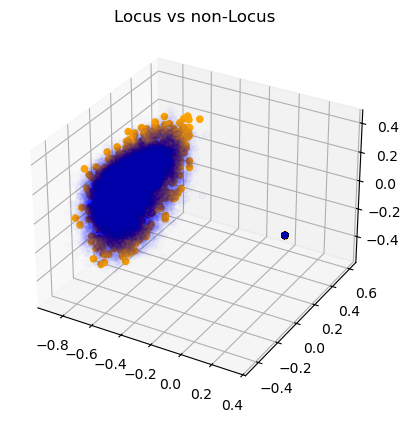

In [27]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter(locus_embed3d.T[0], locus_embed3d.T[1], locus_embed3d.T[2], color='orange', alpha=1.0)
ax.scatter(nonlocus_embed3d.T[0], nonlocus_embed3d.T[1], nonlocus_embed3d.T[2], color='blue', alpha=0.01)

plt.title('Locus vs non-Locus')
plt.show()

Maybe there's something here? It doesn't look quite differentiated, though.

Let's see if we get anything different looking at the Hugo dataset

In [24]:
hugo = sample[sample.hugo]
nonhugo = sample[~(sample.hugo)]

hugo_embed = transformer.encode(np.array(hugo.book_synopsis))
nonhugo_embed = transformer.encode(np.array(nonhugo.book_synopsis)) # these two steps could take a while

In [25]:
hugo3d = pca.transform(hugo_embed)
nonhugo3d = pca.transform(nonhugo_embed)

hugo3d = hugo3d.T
nonhugo3d = nonhugo3d.T

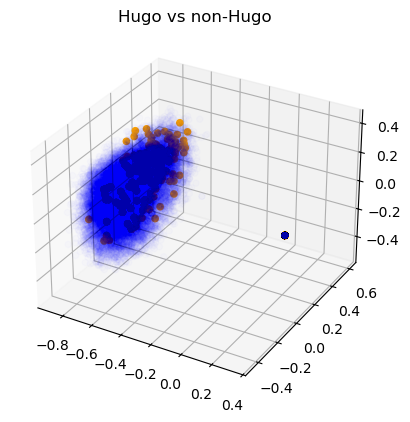

In [28]:
ax = plt.figure().add_subplot(projection= '3d')

ax.scatter(hugo3d[0], hugo3d[1], hugo3d[2], color='orange', alpha = 1.0)
ax.scatter(nonhugo3d[0], nonhugo3d[1], nonhugo3d[2], color='blue', alpha=0.01)

plt.title('Hugo vs non-Hugo')
plt.show()

Again, no discernable difference. Though the Hugo dataset is sparser.

In [33]:
sample['target'] = sample.hugo | sample.locus

target_embed = transformer.encode(np.array(sample[sample.target].book_synopsis))

nontarget_embed = transformer.encode(np.array(sample[~(sample.target)].book_synopsis))

In [34]:
target_3d = pca.transform(target_embed)
nontarget_3d = pca.transform(nontarget_embed)

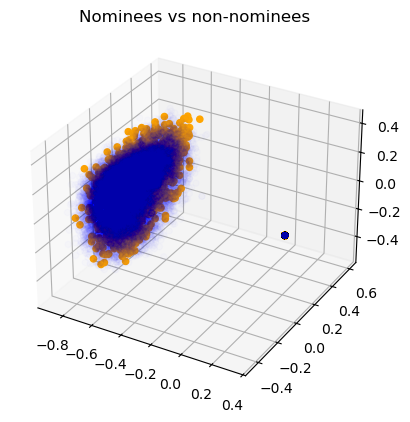

In [35]:
ax = plt.figure().add_subplot(projection= '3d')

ax.scatter(target_3d.T[0], target_3d.T[1], target_3d.T[2], color='orange', alpha = 1.0)
ax.scatter(nontarget_3d.T[0], nontarget_3d.T[1], nontarget_3d.T[2], color='blue', alpha=0.01)

plt.title('Nominees vs non-nominees')
plt.show()